# **Principal Component Analysis**(Data Compression)

In [3153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat



PCA的核心思想是通过线性变换，将原始高维数据投影到一个新的低维坐标系中。这个新坐标系的坐标轴（主成分）是按照**数据方差从大到小**的顺序排列的。

---

### 第一步：中心化（Centering）

这是所有操作的起点。目的是将数据的中心移到原点，便于计算方差和协方差。

**公式：**
$$
\mathbf{x}^{(i)} := \mathbf{x}^{(i)} - \boldsymbol{\mu}
$$
其中，
- $\mathbf{x}^{(i)}$ 是第 $i$ 个样本的原始特征向量（列向量）。
- $\boldsymbol{\mu} = \frac{1}{m} \sum_{i=1}^m \mathbf{x}^{(i)}$ 是所有样本的均值向量。

**矩阵表示：**
将中心化后的 $m$ 个样本（每个样本是 $n$ 维）按行堆叠成数据矩阵 $\mathbf{X}$（$m \times n$ 维），则有：
$$
\mathbf{X}_{\text{centered}} = \mathbf{X} - \mathbf{1} \boldsymbol{\mu}^T
$$
其中 $\mathbf{1}$ 是一个全为1的列向量。

**目的：** 确保数据的均值为零，使得后续的方差计算简化为 $\mathbf{x}^T\mathbf{x}$。

---

### 第二步：计算协方差矩阵（Covariance Matrix）

协方差矩阵 $\mathbf{\Sigma}$ 捕获了数据各个维度（特征）之间的相关性。

**公式：**
$$
\mathbf{\Sigma} = \frac{1}{m} \sum_{i=1}^m \mathbf{x}^{(i)} (\mathbf{x}^{(i)})^T = \frac{1}{m} \mathbf{X}_{\text{centered}}^T \mathbf{X}_{\text{centered}}
$$
其中，
- $\mathbf{\Sigma}$ 是一个 $n \times n$ 的对称矩阵。
- 对角线上的元素 $\Sigma_{jj}$ 是第 $j$ 个特征的**方差**。
- 非对角线上的元素 $\Sigma_{jk}$ 是第 $j$ 个特征和第 $k$ 个特征的**协方差**。

**目的：** 量化数据中各维度之间的关系。PCA的目标就是让新坐标系下的维度间协方差为0（不相关）。

---

### 第三步：特征分解（Eigen Decomposition）

这是PCA的**数学核心**。我们需要找到协方差矩阵 $\mathbf{\Sigma}$ 的特征值和特征向量。

**公式：**
$$
\mathbf{\Sigma} \mathbf{w} = \lambda \mathbf{w}
$$
其中，
- $\lambda$ 是一个**标量**，称为**特征值**。
- $\mathbf{w}$ 是一个 $n$ 维**向量**，称为**特征向量**。

**几何解释：**
特征向量 $\mathbf{w}$ 定义了一个方向，数据在这个方向上的投影方差恰好等于特征值 $\lambda$。**特征值 $\lambda$ 的大小直接代表了数据在该特征向量方向上方差的大小。**

**求解：**
通常求解特征方程 $|\mathbf{\Sigma} - \lambda \mathbf{I}| = 0$ 得到所有特征值 $\lambda_1, \lambda_2, ..., \lambda_n$，再代入原方程求出对应的特征向量 $\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_n$。

**目的：** 找到数据方差最大的方向（即最大特征值对应的特征向量）。

---

### 第四步：选择主成分并构建投影矩阵

我们需要选择最重要的 $k$ 个主成分来降维。

1.  **排序**：将特征值从大到小排序：$\lambda_1 > \lambda_2 > ... > \lambda_n$。
    其对应的特征向量也按相同顺序排列：$\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_n$。

2.  **选择k**：选择前 $k$ 个最大的特征值对应的特征向量。
    通常根据**方差解释率（Explained Variance Ratio）**来选择 $k$：
    $$
    \text{Explained Variance Ratio of } \mathbf{w}_j = \frac{\lambda_j}{\sum_{i=1}^n \lambda_i}
    $$
    我们选择最小的 $k$，使得累计方差解释率满足要求（例如 >95%）：
    $$
    \frac{\sum_{j=1}^k \lambda_j}{\sum_{i=1}^n \lambda_i} \geq 0.95
    $$

3.  **构建投影矩阵**：将选定的 $k$ 个特征向量（列向量）并排组成投影矩阵 $\mathbf{W}$。
    $$
    \mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_k]
    $$
    $\mathbf{W}$ 是一个 $n \times k$ 的矩阵。

**目的：** 构建一个从原始 $n$ 维空间到新 $k$ 维空间的投影映射。

---

### 第五步：投影数据（得到降维后的结果）

将中心化后的原始数据投影到新的主成分方向上，得到降维后的新数据 $\mathbf{Z}$。

**公式：**
$$
\mathbf{z}^{(i)} = \mathbf{W}^T \mathbf{x}^{(i)}
$$
其中，
- $\mathbf{z}^{(i)}$ 是样本 $i$ 在 $k$ 维新空间中的坐标（一个 $k$ 维列向量）。

**矩阵表示（最常用）：**
$$
\mathbf{Z} = \mathbf{X}_{\text{centered}} \mathbf{W}
$$
其中，
- $\mathbf{X}_{\text{centered}}$ 是 $m \times n$ 的中心化数据矩阵。
- $\mathbf{W}$ 是 $n \times k$ 的投影矩阵。
- $\mathbf{Z}$ 是 $m \times k$ 的降维后的新数据矩阵。

**目的：** 得到降维后且各维度不相关的数据集。

---

### 总结：PCA的数学目标

从优化角度看，PCA求解的是一个**最大化方差**的问题。

**第一主成分 $\mathbf{w}_1$ 的求解：**
$$
\begin{align*}
&\max_{\mathbf{w}_1} \quad \frac{1}{m} \sum_{i=1}^m (\mathbf{w}_1^T \mathbf{x}^{(i)})^2 = \mathbf{w}_1^T \mathbf{\Sigma} \mathbf{w}_1 \\
&\text{subject to} \quad \|\mathbf{w}_1\|^2_2 = 1
\end{align*}
$$
**约束条件 $\|\mathbf{w}_1\|_2 = 1$ 是为了确保解是唯一的方向，而不是无限长。**

**后续主成分的求解：**
第 $j$ 个主成分 $\mathbf{w}_j$ 不仅要最大化方差，还必须与之前的所有主成分正交（不相关）：
$$
\begin{align*}
&\max_{\mathbf{w}_j} \quad \mathbf{w}_j^T \mathbf{\Sigma} \mathbf{w}_j \\
&\text{subject to} \quad \|\mathbf{w}_j\|^2_2 = 1, \quad \mathbf{w}_j^T \mathbf{w}_i = 0 \quad \text{for all } i < j
\end{align*}
$$

**而特征分解（$\mathbf{\Sigma} \mathbf{w} = \lambda \mathbf{w}$）恰好是这个优化问题的最优解。** 最大的特征值 $\lambda_1$ 对应最大方差，其特征向量 $\mathbf{w}_1$ 就是第一主成分的方向。

通过这一系列的数学步骤，PCA成功地将原始相关的高维数据，转换成了用一组**互不相关**、**按方差大小排序**的**新特征**表示的低维数据。

In [3154]:
data = loadmat('data/ex7data1.mat')
X = data['X']

# check
X.shape
(np.sum(X,axis=1)/X.shape[0]).shape

(50,)

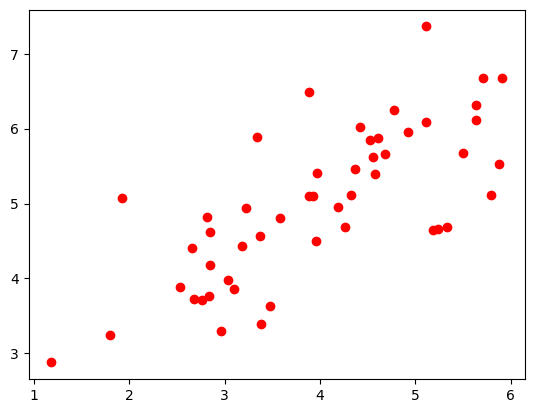

In [3155]:
# scatter the point
plt.scatter(X[:,0],X[:,1],c='r',marker='o')
plt.show()

In [3156]:
def PCA(X:np.ndarray,k:int)->tuple[np.ndarray,np.ndarray]:
    """
    X:(m,n)  m samples, n dimension
    """
    # 1.Standardization (or centering, we choose standardization here)
    m,n = X.shape
    if (k>n):
        return X
    
    mu = np.sum(X,axis=0)/m
    sigma = np.sqrt(np.sum(np.power(X-mu,2),axis=0)/m) # /m-1  可以获得无偏估计
    X_std = (X - mu)/sigma

    Cov = (X_std.T @ X_std)/m # (n,n)
    print(Cov)

    # find features values and vectors
    eigen_values,eigen_vects = np.linalg.eig(Cov)
    # print(eigen_vects)

    # fetch the largest k features values (meaning to reduce dimension to k)
    sorted_idx = np.argsort(eigen_values)[::-1]# [strat:end:step] 获得升序数组反转为降序

    # eigen_values = eigen_values[sorted_idx][:k]
    eigen_vects = eigen_vects[:,sorted_idx]
    print(eigen_vects)
    eigen_vects = eigen_vects[:,:k] # (n,k)

    # print(eigen_vects)

    # project data
    X_pca = X @ (eigen_vects) # (m,n)x(n,k)

    # print(X_pca)

    return X_pca,eigen_vects

In [3157]:
# apply pca
m,n=X.shape
X_pca,U= PCA(X,n-1)


[[1.         0.73553038]
 [0.73553038 1.        ]]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


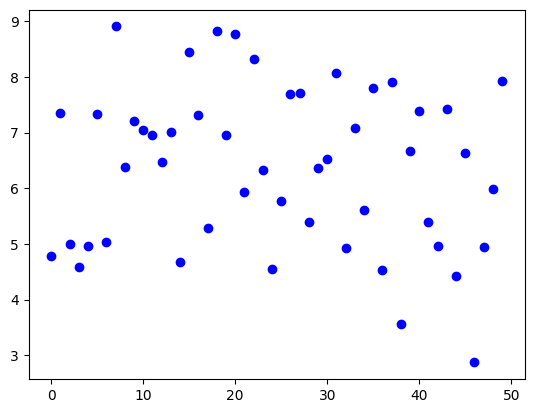

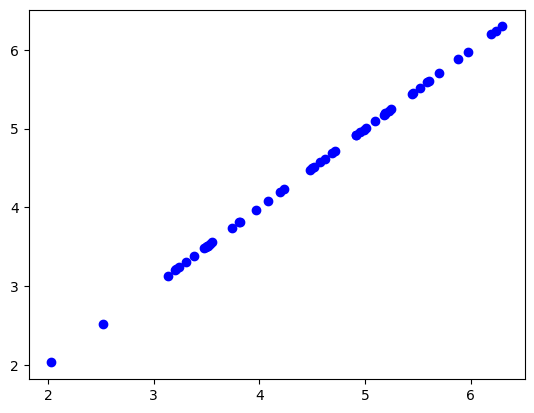

In [3158]:

plt.scatter(np.arange(m),(X_pca[:,0]),c='b',marker='o')
plt.show()

X_pca = np.dot(X_pca,U.T)
plt.scatter(X_pca[:,0],X_pca[:,1],c='b',marker='o')

In [3159]:
# 简洁写法
def pca(X,k)->tuple[np.ndarray,np.ndarray]:
    X_std=(X-X.mean(axis=0))/X.std(axis=0)
    Cov = (X_std.T @ X_std)/X_std.shape[0]
    print(Cov)

    P,A,P_T = np.linalg.svd(Cov) # 分解对角矩阵
    vects = P[:,:k]
    print(P)
    # print(vects)
    
    X_pca = X @ vects
    # print(X_pca)

    return X_pca, vects
    

In [3160]:
# 宗中心化的方式不同
def pca2(X,k):
    X_std=(X-X.mean())/X.std()
    Cov = (X_std.T @ X_std)/X_std.shape[0]
    
    P,A,P_T = np.linalg.svd(Cov) # 分解对角矩阵
    vects = P[:,:k]
    
    X_output = X @ vects
    
    X_output = X_output @ vects.T
    return X_output
    

In [3161]:
def pca_outputstd(X,k)->tuple[np.ndarray,np.ndarray]:
    X_std=(X-X.mean(axis=0))/X.std(axis=0)
    Cov = (X_std.T @ X_std)/X_std.shape[0]
    P,A,P_T = np.linalg.svd(Cov) # 分解对角矩阵
    vects = P[:,:k]
    # print(vects)
    
    X_pca = X_std @ vects
    # print(X_pca)

    return X_pca, vects

In [3162]:
# apply pca
m,n=X.shape
X_pca ,U= pca(X,n-1)

[[1.         0.73553038]
 [0.73553038 1.        ]]
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


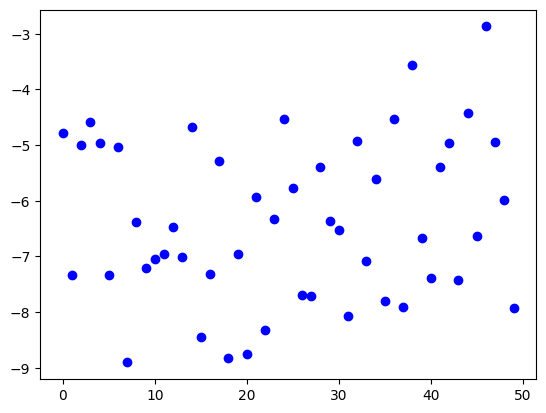

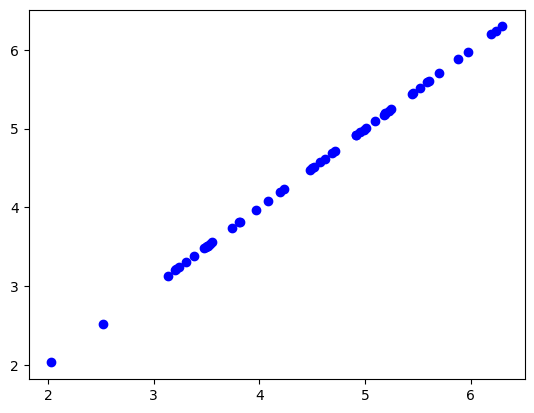

In [3163]:

plt.scatter(np.arange(m),(X_pca[:,0]),c='b',marker='o')
plt.show()

X_pca = np.dot(X_pca,U.T)
plt.scatter(X_pca[:,0],X_pca[:,1],c='b',marker='o')

### 接下来对脸部图像做降维处理提取脸部特征

In [3164]:
faces = loadmat('data/ex7faces.mat')
X = faces['X']
X.shape
# 反色处理
X = 255-np.abs(X)


In [3165]:
img_width = int(np.sqrt(1024))

In [3166]:
def plot_n_images(X:np.ndarray,width:int=5)->np.ndarray:
    num,size = X.shape
    img_width = int(np.sqrt(size))
    merged_img = np.zeros((num*img_width,width*img_width))
    for i in range(num):
        img = X[i]
        img = img.reshape(img_width,-1).T
        pos_y = int(i/width)
        pos_x = i % width
        merged_img[\
            pos_y*img_width: (pos_y+1)*img_width,\
            pos_x*img_width: (pos_x+1)*img_width
            ]=img
    return merged_img

In [3167]:
imges = plot_n_images(X)
imges

array([[217.13368613, 229.13368613, 238.13368613, ..., 239.13368613,
        234.13368613, 233.13368613],
       [209.13368613, 221.13368613, 238.13368613, ..., 248.86631387,
        241.13368613, 232.13368613],
       [201.13368613, 216.13368613, 230.13368613, ..., 244.86631387,
        251.13368613, 233.13368613],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

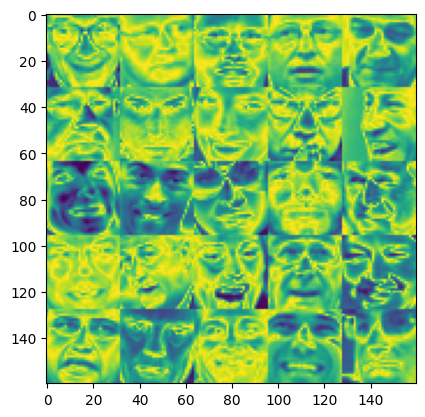

In [3168]:
plt.imshow(imges[:5*img_width,:].astype('uint8'))

可以看出来这些是一些灰度图像

(5000, 1024)


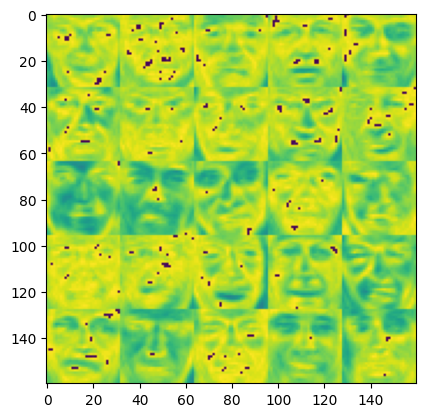

In [3169]:
X_plot=pca2(X,100)
print(X_plot.shape)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)

plt.imshow(imges_pca[:5*img_width,:].astype('uint8'))


[[ 1.          0.9567723   0.86817204 ... -0.04870453 -0.05514023
  -0.04315866]
 [ 0.9567723   1.          0.94529698 ... -0.05440915 -0.06011686
  -0.04728198]
 [ 0.86817204  0.94529698  1.         ... -0.0621343  -0.06716277
  -0.05590484]
 ...
 [-0.04870453 -0.05440915 -0.0621343  ...  1.          0.93284538
   0.83538855]
 [-0.05514023 -0.06011686 -0.06716277 ...  0.93284538  1.
   0.93326423]
 [-0.04315866 -0.04728198 -0.05590484 ...  0.83538855  0.93326423
   1.        ]]
[[-0.01442493 -0.03156498 -0.02869499 ...  0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ... -0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ...  0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ... -0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ...  0.00505935 -0.00027697
   0.00360244]
 [-0.00877221 -0.00270805  0.03547118 ... -0.00136177 -0.00046711
  -0.00548405]]


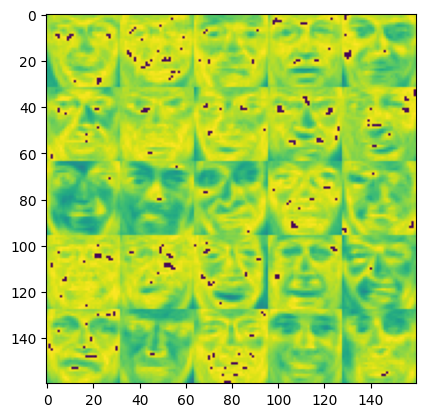

In [3170]:
# X_pca,U = PCA(X,100)
X_pca,U = pca(X,100)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)

plt.imshow(imges_pca[0*img_width:5*img_width,:].astype('uint8'))

[[ 1.          0.9567723   0.86817204 ... -0.04870453 -0.05514023
  -0.04315866]
 [ 0.9567723   1.          0.94529698 ... -0.05440915 -0.06011686
  -0.04728198]
 [ 0.86817204  0.94529698  1.         ... -0.0621343  -0.06716277
  -0.05590484]
 ...
 [-0.04870453 -0.05440915 -0.0621343  ...  1.          0.93284538
   0.83538855]
 [-0.05514023 -0.06011686 -0.06716277 ...  0.93284538  1.
   0.93326423]
 [-0.04315866 -0.04728198 -0.05590484 ...  0.83538855  0.93326423
   1.        ]]
[[-0.01442493 -0.03156498 -0.02869499 ...  0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ... -0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ...  0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ... -0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ...  0.00505935 -0.00027697
   0.00360244]
 [-0.00877221 -0.00270805  0.03547118 ... -0.00136177 -0.00046711
  -0.00548405]]


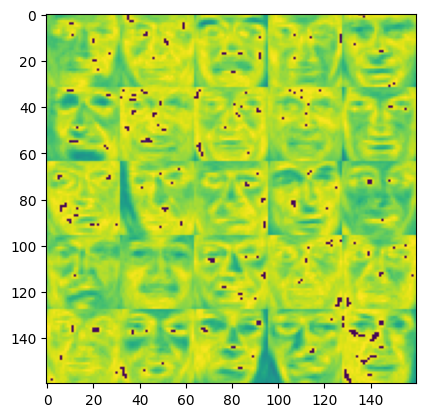

In [3171]:
X_pca,U = PCA(X,100)
# X_pca,U = pca(X,100)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

[[ 1.          0.9567723   0.86817204 ... -0.04870453 -0.05514023
  -0.04315866]
 [ 0.9567723   1.          0.94529698 ... -0.05440915 -0.06011686
  -0.04728198]
 [ 0.86817204  0.94529698  1.         ... -0.0621343  -0.06716277
  -0.05590484]
 ...
 [-0.04870453 -0.05440915 -0.0621343  ...  1.          0.93284538
   0.83538855]
 [-0.05514023 -0.06011686 -0.06716277 ...  0.93284538  1.
   0.93326423]
 [-0.04315866 -0.04728198 -0.05590484 ...  0.83538855  0.93326423
   1.        ]]
[[-0.01442493 -0.03156498 -0.02869499 ...  0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ... -0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ...  0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ... -0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ...  0.00505935 -0.00027697
   0.00360244]
 [-0.00877221 -0.00270805  0.03547118 ... -0.00136177 -0.00046711
  -0.00548405]]


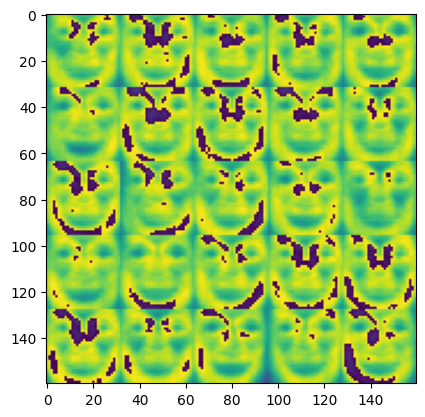

In [3172]:
X_pca,U = PCA(X,10)
# X_pca,U = pca(X,100)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

### 对比输出投射归一化X数据集的结果

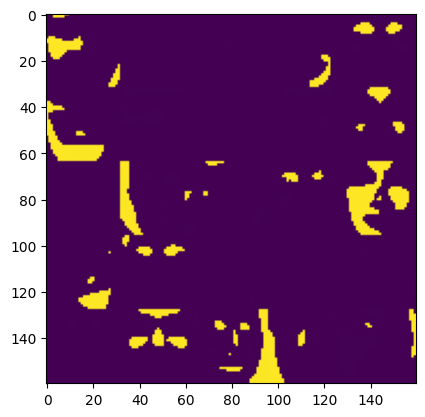

In [3173]:
X_pca,U = pca_outputstd(X,10)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

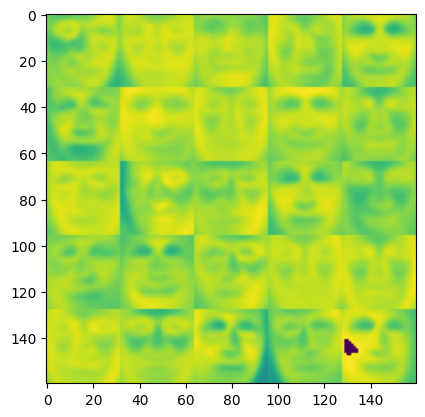

In [3174]:
X_unstd = X_plot * X.std(axis=0)+X.mean(axis=0)
imges_pca = plot_n_images(X_unstd)
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

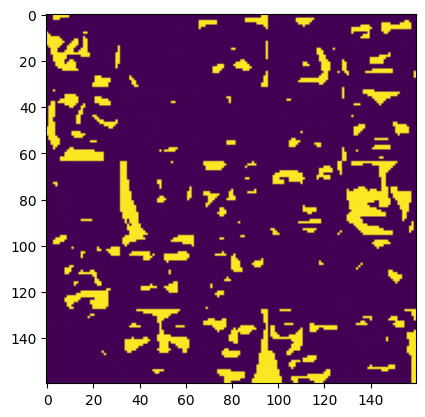

In [3175]:
X_pca,U = pca_outputstd(X,100)

X_plot = np.dot(X_pca,U.T)

img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))


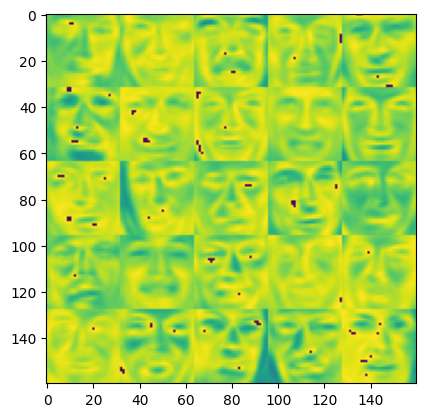

In [3176]:
X_unstd = X_plot * X.std(axis=0)+X.mean(axis=0)
imges_pca = plot_n_images(X_unstd)
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

为什么输出的时候使用x不使用x_std一样可以输出降维结果
,这是因为你在PCA降维和重构时，**只要主成分方向（特征向量）是正交的**，用原始数据 `X` 还是标准化数据 `X_std`，都可以做投影和重构，但结果会有本质区别：

---

### 1. 用 `X`（原始数据）做PCA

- 你直接用原始数据 `X` 乘以主成分向量 `U` 得到降维结果，再用 `U.T` 投影回原空间。
- 这样做**数学上是成立的**，但主成分的方向是基于标准化数据（或中心化数据）算出来的，直接用原始数据投影，主成分的意义会变。
- 结果通常会丢失均值和方差信息，重构出来的图片可能亮度、对比度不对，但结构还在。

---

### 2. 用 `X_std`（标准化数据）做PCA

- 这是PCA的标准做法，主成分方向是基于标准化数据算的，降维和重构都在标准化空间进行。
- 最后如果要还原到原始空间，需要**反标准化**（乘以标准差，加上均值）。

---

### 3. 为什么直接用 `X` 也能看到降维效果？

- 因为主成分向量 `U` 是正交的，`X @ U @ U.T` 实际上是把 `X` 投影到主成分空间再投影回来，等价于在原空间做了一个“低秩近似”。
- 这相当于用主成分方向对原始数据做了一个“最佳拟合”，即使没标准化，结构信息依然能保留，只是亮度/对比度可能不准。

---

### 4. 总结

- **标准做法**：PCA前先中心化/标准化，降维和重构都在标准化空间，最后反标准化还原。
- **直接用X也能降维**，但主成分的物理意义会变，重构结果可能有偏移，但结构信息还在。

---

**建议：**  
如果你想让重构结果和原图亮度、对比度一致，建议用标准化数据做PCA，最后反标准化还原。如果只关心结构，直接用 `X` 也可以看到降维效果。